In [10]:
import os
from tqdm import tqdm
import torch
import numpy as np
from dataset import process_dataset
from scaler import VitalScaler
from evaluate_alerting import evaluate_alert_hitrate, summarize_alert_hitrate

In [2]:
#1. Load and Process Data
train_df, test_df = process_dataset(test_mode=False) 

#Normalize Data and Save Scaler
print("loading datasets...")
scaler = VitalScaler()
scaler.fit(train_df)

loading datasets...


In [9]:
out_path = '../../outputs/Diffusion'

targets = ['HR', 'RESP', 'SpO2']

alerts = []

for batch_name in tqdm(os.listdir(out_path)):
    batch_path = f'{out_path}/{batch_name}'

    encoder_target = scaler.inverse(np.load(f'{batch_path}/encoder_target.npy'))
    decoder_target = scaler.inverse(np.load(f'{batch_path}/decoder_target.npy'))
    samples = np.load(f'{batch_path}/samples.npy')
    median_pred = np.median(samples, axis=0)

    for i in range(decoder_target.shape[0]):
        gts = encoder_target[i]
        preds = median_pred[i]
        for j in range(3):
            vital = targets[j]
            gt = gts[:, j]
            pred = preds[:, j]

            alert = evaluate_alert_hitrate(pred, gt, vital)
            alerts.append(alert)

100%|██████████| 840/840 [04:52<00:00,  2.87it/s]


=== Alert Hit Rate by Vital ===
         Hits   Total HitRate
Vital                        
HR     386090  430030   89.8%
RESP   151962  430030   35.3%
SpO2   287131  430030   66.8%

=== Per-Vital Classification Report ===

--- HR ---
              precision    recall  f1-score   support

      stable       0.90      1.00      0.95    351692
     warning       0.83      0.45      0.59     63998
   emergency       0.99      0.38      0.55     14340

    accuracy                           0.90    430030
   macro avg       0.91      0.61      0.69    430030
weighted avg       0.89      0.90      0.88    430030


--- RESP ---
              precision    recall  f1-score   support

      stable       0.16      0.97      0.27     35213
     warning       0.34      0.32      0.33    153962
   emergency       1.00      0.28      0.44    240855

    accuracy                           0.35    430030
   macro avg       0.50      0.53      0.35    430030
weighted avg       0.70      0.35      0.39 

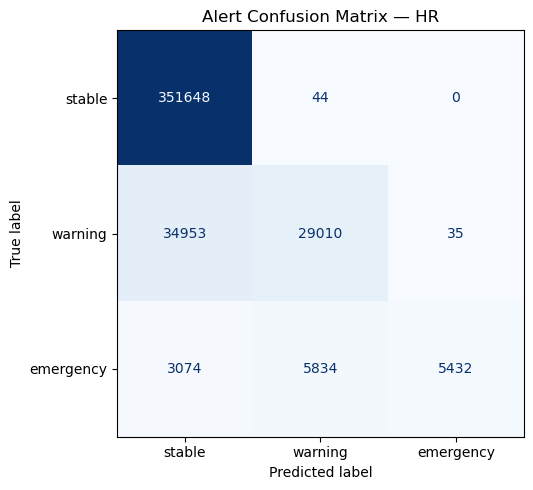

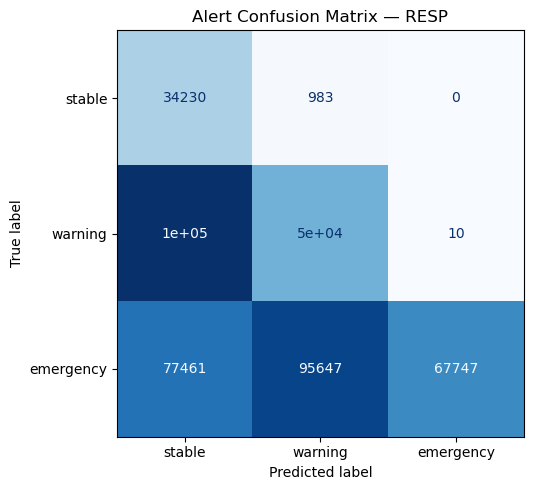

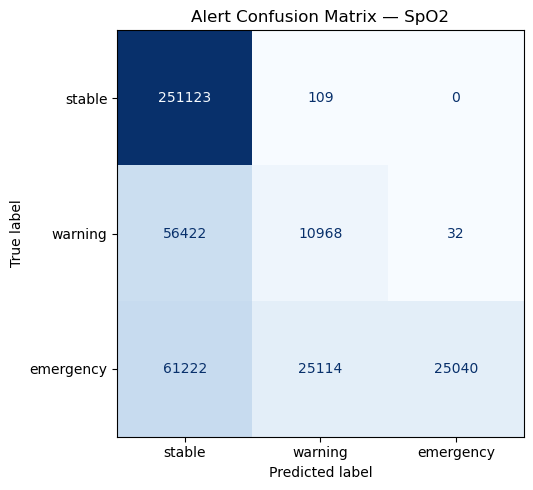

In [11]:
alerts_df = summarize_alert_hitrate(alerts)